# Transformer Attention Head 역할 분화 분석 실험

---

Dataset: Portuguese → English (opus-100 en-pt)  
Framework: TensorFlow 2.x  

세 가지 질문에 답하는 게 목표

- RQ1. 각 Head는 실제로 서로 다른 패턴을 학습하는가?
- RQ2. Head 수를 바꾸면 번역 성능이 어떻게 달라지는가?
- RQ3. 학습 후 불필요한 Head를 제거해도 성능이 유지되는가?

---

**고정 하이퍼파라미터**

| 파라미터 | 값 |
|---|---|
| d_model | 96 |
| num_layers | 3 |
| dff | 384 |
| dropout | 0.1 |
| batch_size | 128 |
| max_tokens | 64 |
| seed | 42 |

In [1]:
# Cell 1: 환경 설정
!pip uninstall -y -q tensorflow keras tensorflow-estimator tensorflow-text
!pip install -q -U tensorflow tensorflow-text tensorflow-datasets
!pip install -q nltk datasets

import logging
import time
import gc
import json
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_text
import nltk
nltk.download('punkt_tab')
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from tensorflow.keras.callbacks import EarlyStopping

# 한글 폰트 설정 (그래프 깨짐 방지)
!apt-get install -q fonts-nanum
matplotlib.font_manager._load_fontmanager(try_read_cache=False)
plt.rcParams['font.family'] = 'NanumGothic'

print("GPU:", tf.config.list_physical_devices("GPU"))
print("TensorFlow:", tf.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 MB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 37.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tf-keras 2.19.0 requires tensorflow<2.20,>=2.19, but you have tensorflow 2.20.0 which is incompatible.
tensorflow-decision-forests 1.12.0 requires tensorflow==2.19.0, but you have tensorflow 2.20.0 which is incompatible.


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Reading package lists...
Building dependency tree...
Reading state information...
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 42 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (12.0 MB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 122354 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow: 2.20.0


In [2]:
# Cell 2: 데이터 로드
# 원래 가이드라인은 tfds의 ted_hrlr_translate/pt_to_en을 사용하도록 했으나
# 원본 서버(phontron.com)가 다운된 상태라 서치 후 동일한 pt-en 병렬 코퍼스인
# Helsinki-NLP/opus-100으로 대체함, 토크나이저는 가이드라인 그대로 사용.
from datasets import load_dataset
from huggingface_hub import login
from google.colab import userdata

login(token=userdata.get('HF_TOKEN'))

dataset = load_dataset("Helsinki-NLP/opus-100", "en-pt")

train_examples = [{'pt': d['translation']['pt'], 'en': d['translation']['en']}
                  for d in dataset['train']]
val_examples   = [{'pt': d['translation']['pt'], 'en': d['translation']['en']}
                  for d in dataset['validation']]

print(f"훈련: {len(train_examples)}개")
print(f"검증: {len(val_examples)}개")

README.md: 0.00B [00:00, ?B/s]

en-pt/test-00000-of-00001.parquet:   0%|          | 0.00/220k [00:00<?, ?B/s]

en-pt/train-00000-of-00001.parquet:   0%|          | 0.00/87.2M [00:00<?, ?B/s]

en-pt/validation-00000-of-00001.parquet:   0%|          | 0.00/217k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/1000000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

훈련: 1000000개
검증: 2000개


In [3]:
# Cell 3: 토크나이저 + 데이터 파이프라인
MAX_TOKENS  = 64
BUFFER_SIZE = 20000
BATCH_SIZE  = 128

model_name = 'ted_hrlr_translate_pt_en_converter'
tf.keras.utils.get_file(
    f'{model_name}.zip',
    f'https://storage.googleapis.com/download.tensorflow.org/models/{model_name}.zip',
    cache_dir='.', cache_subdir='', extract=True
)
tokenizers = tf.saved_model.load(f'./{model_name}_extracted/{model_name}')
print("포르투갈어 어휘 크기:", tokenizers.pt.get_vocab_size().numpy())
print("영어 어휘 크기:",       tokenizers.en.get_vocab_size().numpy())

PT_VOCAB_SIZE = int(tokenizers.pt.get_vocab_size().numpy())
EN_VOCAB_SIZE = int(tokenizers.en.get_vocab_size().numpy())

def make_batches(data_list, num_samples=5000):
    data_list = data_list[:num_samples]
    pt_texts  = [d['pt'] for d in data_list]
    en_texts  = [d['en'] for d in data_list]
    ds = tf.data.Dataset.from_tensor_slices((pt_texts, en_texts))

    def prepare_batch(pt, en):
        pt = tokenizers.pt.tokenize(tf.expand_dims(pt, 0))
        pt = pt[:, :MAX_TOKENS].to_tensor()
        en = tokenizers.en.tokenize(tf.expand_dims(en, 0))
        en = en[:, :(MAX_TOKENS + 1)]
        en_inputs = en[:, :-1].to_tensor()
        en_labels = en[:, 1:].to_tensor()
        return (tf.squeeze(pt, 0), tf.squeeze(en_inputs, 0)), tf.squeeze(en_labels, 0)

    return (
        ds
        .shuffle(BUFFER_SIZE)
        .map(prepare_batch, num_parallel_calls=tf.data.AUTOTUNE)
        .padded_batch(BATCH_SIZE, padded_shapes=(([MAX_TOKENS], [MAX_TOKENS]), [MAX_TOKENS]))
        .prefetch(tf.data.AUTOTUNE)
    )

train_batches = make_batches(train_examples, num_samples=5000)
val_batches   = make_batches(val_examples,   num_samples=500)

for (pt, en), en_labels in train_batches.take(1):
    print(f"포르투갈어 입력 shape: {pt.shape}")
    print(f"영어 입력 shape:       {en.shape}")
    print(f"영어 레이블 shape:     {en_labels.shape}")
    break

184801/184801 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
포르투갈어 어휘 크기: 7765
영어 어휘 크기: 7010
포르투갈어 입력 shape: (128, 64)
영어 입력 shape:       (128, 64)
영어 레이블 shape:     (128, 64)


---
# Transformer 모델 구현

In [4]:
# Cell 4: Positional Encoding
def positional_encoding(length, depth):
    depth = depth / 2
    positions   = np.arange(length)[:, np.newaxis]
    depths      = np.arange(depth)[np.newaxis, :] / depth
    angle_rates = 1 / (10000 ** depths)
    angle_rads  = positions * angle_rates
    pos_encoding = np.concatenate([np.sin(angle_rads), np.cos(angle_rads)], axis=-1)
    return tf.cast(pos_encoding, dtype=tf.float32)

In [5]:
# Cell 5: Positional Embedding
class PositionalEmbedding(tf.keras.layers.Layer):
    def __init__(self, vocab_size, d_model):
        super().__init__()
        self.d_model   = d_model
        self.embedding = tf.keras.layers.Embedding(vocab_size, d_model, mask_zero=True)
        self.pos_encoding = positional_encoding(length=2048, depth=d_model)

    def compute_mask(self, *args, **kwargs):
        return self.embedding.compute_mask(*args, **kwargs)

    def call(self, x):
        length = tf.shape(x)[1]
        x = self.embedding(x)
        x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))
        x  = x + self.pos_encoding[tf.newaxis, :length, :]
        return x

In [6]:
# Cell 6: Attention Layers
class BaseAttention(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super().__init__()
        self.mha       = tf.keras.layers.MultiHeadAttention(**kwargs)
        self.layernorm = tf.keras.layers.LayerNormalization()
        self.add       = tf.keras.layers.Add()

class GlobalSelfAttention(BaseAttention):
    # return_attention_scores=True로 Head별 가중치를 저장 — 실험 A, C의 기반
    def call(self, x):
        attn_output, attn_scores = self.mha(
            query=x, value=x, key=x, return_attention_scores=True)
        self.last_attn_scores = attn_scores
        x = self.add([x, attn_output])
        x = self.layernorm(x)
        return x

class CausalSelfAttention(BaseAttention):
    def call(self, x):
        attn_output, attn_scores = self.mha(
            query=x, value=x, key=x,
            use_causal_mask=True, return_attention_scores=True)
        self.last_attn_scores = attn_scores
        x = self.add([x, attn_output])
        x = self.layernorm(x)
        return x

class CrossAttention(BaseAttention):
    def call(self, x, context):
        attn_output, attn_scores = self.mha(
            query=x, key=context, value=context, return_attention_scores=True)
        self.last_attn_scores = attn_scores
        x = self.add([x, attn_output])
        x = self.layernorm(x)
        return x

In [7]:
# Cell 7: Feed Forward Network
class FeedForward(tf.keras.layers.Layer):
    def __init__(self, d_model, dff, dropout_rate=0.1):
        super().__init__()
        self.seq = tf.keras.Sequential([
            tf.keras.layers.Dense(dff, activation='relu'),
            tf.keras.layers.Dense(d_model),
            tf.keras.layers.Dropout(dropout_rate)
        ])
        self.add        = tf.keras.layers.Add()
        self.layer_norm = tf.keras.layers.LayerNormalization()

    def call(self, x):
        x = self.add([x, self.seq(x)])
        x = self.layer_norm(x)
        return x

In [8]:
# Cell 8: Encoder
class EncoderLayer(tf.keras.layers.Layer):
    def __init__(self, *, d_model, num_heads, dff, dropout_rate=0.1):
        super().__init__()
        self.self_attention = GlobalSelfAttention(
            num_heads=num_heads, key_dim=d_model // num_heads, dropout=dropout_rate)
        self.ffn = FeedForward(d_model, dff, dropout_rate)

    def call(self, x):
        x = self.self_attention(x)
        x = self.ffn(x)
        return x

class Encoder(tf.keras.layers.Layer):
    def __init__(self, *, num_layers, d_model, num_heads, dff, vocab_size, dropout_rate=0.1):
        super().__init__()
        self.d_model    = d_model
        self.num_layers = num_layers
        self.pos_embedding = PositionalEmbedding(vocab_size=vocab_size, d_model=d_model)
        self.enc_layers = [
            EncoderLayer(d_model=d_model, num_heads=num_heads, dff=dff, dropout_rate=dropout_rate)
            for _ in range(num_layers)
        ]
        self.dropout = tf.keras.layers.Dropout(dropout_rate)

    def call(self, x):
        x = self.pos_embedding(x)
        x = self.dropout(x)
        for enc_layer in self.enc_layers:
            x = enc_layer(x)
        return x

In [9]:
# Cell 9: Decoder
class DecoderLayer(tf.keras.layers.Layer):
    def __init__(self, *, d_model, num_heads, dff, dropout_rate=0.1):
        super().__init__()
        self.causal_self_attention = CausalSelfAttention(
            num_heads=num_heads, key_dim=d_model // num_heads, dropout=dropout_rate)
        self.cross_attention = CrossAttention(
            num_heads=num_heads, key_dim=d_model // num_heads, dropout=dropout_rate)
        self.ffn = FeedForward(d_model, dff, dropout_rate)

    def call(self, x, context):
        x = self.causal_self_attention(x)
        x = self.cross_attention(x, context)
        self.last_attn_scores = self.cross_attention.last_attn_scores
        x = self.ffn(x)
        return x

class Decoder(tf.keras.layers.Layer):
    def __init__(self, *, num_layers, d_model, num_heads, dff, vocab_size, dropout_rate=0.1):
        super(Decoder, self).__init__()
        self.d_model    = d_model
        self.num_layers = num_layers
        self.pos_embedding = PositionalEmbedding(vocab_size=vocab_size, d_model=d_model)
        self.dropout  = tf.keras.layers.Dropout(dropout_rate)
        self.dec_layers = [
            DecoderLayer(d_model=d_model, num_heads=num_heads, dff=dff, dropout_rate=dropout_rate)
            for _ in range(num_layers)
        ]
        self.last_attn_scores = None

    def call(self, x, context):
        x = self.pos_embedding(x)
        x = self.dropout(x)
        for dec_layer in self.dec_layers:
            x = dec_layer(x, context)
        self.last_attn_scores = self.dec_layers[-1].last_attn_scores
        return x

In [10]:
# Cell 10: Transformer
class Transformer(tf.keras.Model):
    def __init__(self, *, num_layers, d_model, num_heads, dff,
                 input_vocab_size, target_vocab_size, dropout_rate=0.1):
        super().__init__()
        self.encoder = Encoder(
            num_layers=num_layers, d_model=d_model, num_heads=num_heads, dff=dff,
            vocab_size=input_vocab_size, dropout_rate=dropout_rate)
        self.decoder = Decoder(
            num_layers=num_layers, d_model=d_model, num_heads=num_heads, dff=dff,
            vocab_size=target_vocab_size, dropout_rate=dropout_rate)
        self.final_layer = tf.keras.layers.Dense(target_vocab_size)

    def call(self, inputs):
        context, x = inputs
        context = self.encoder(context)
        x       = self.decoder(x, context)
        logits  = self.final_layer(x)
        try:
            del logits._keras_mask
        except AttributeError:
            pass
        return logits

In [11]:
# Cell 11: Loss / Accuracy / Learning Rate Schedule
def masked_loss(label, pred):
    mask = label != 0
    loss_object = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction='none')
    loss = loss_object(label, pred)
    mask = tf.cast(mask, dtype=loss.dtype)
    loss *= mask
    return tf.reduce_sum(loss) / tf.reduce_sum(mask)

def masked_accuracy(label, pred):
    pred  = tf.argmax(pred, axis=2)
    label = tf.cast(label, pred.dtype)
    match = label == pred
    mask  = label != 0
    match = match & mask
    match = tf.cast(match, dtype=tf.float32)
    mask  = tf.cast(mask,  dtype=tf.float32)
    return tf.reduce_sum(match) / tf.reduce_sum(mask)

class CustomSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, d_model, warmup_steps=2000):
        super().__init__()
        self.d_model      = tf.cast(d_model, tf.float32)
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        step = tf.cast(step, dtype=tf.float32)
        arg1 = tf.math.rsqrt(step)
        arg2 = step * (self.warmup_steps ** -1.5)
        return tf.math.rsqrt(self.d_model) * tf.math.minimum(arg1, arg2)

In [12]:
# Cell 12: Translator (추론용)
class Translator(tf.Module):
    def __init__(self, tokenizers, transformer):
        self.tokenizers  = tokenizers
        self.transformer = transformer

    def __call__(self, sentence, max_length=MAX_TOKENS):
        if isinstance(sentence, str):
            sentence = tf.constant(sentence)
        if len(sentence.shape) == 0:
            sentence = sentence[tf.newaxis]

        sentence      = self.tokenizers.pt.tokenize(sentence).to_tensor()
        encoder_input = sentence

        start_end = self.tokenizers.en.tokenize([''])[0]
        start = start_end[0][tf.newaxis]
        end   = start_end[1][tf.newaxis]

        output_array = tf.TensorArray(dtype=tf.int64, size=0, dynamic_size=True)
        output_array = output_array.write(0, start)

        for i in tf.range(max_length):
            output      = tf.transpose(output_array.stack())
            predictions = self.transformer((encoder_input, output), training=False)
            predictions  = predictions[:, -1:, :]
            predicted_id = tf.argmax(predictions, axis=-1)
            output_array = output_array.write(i + 1, predicted_id[0])
            if predicted_id == end:
                break

        output = tf.transpose(output_array.stack())
        text   = self.tokenizers.en.detokenize(output)[0]
        tokens = self.tokenizers.en.lookup(output)[0]

        self.transformer((encoder_input, output[:, :-1]), training=False)
        attn_weights = self.transformer.decoder.last_attn_scores
        return text, tokens, attn_weights

In [13]:
# Cell 13: 학습 자동화 함수
def train_transformer(num_heads, d_model=96, num_layers=3, dff=384, epochs=30, seed=42):
    tf.random.set_seed(seed)
    np.random.seed(seed)

    transformer = Transformer(
        num_layers=num_layers, d_model=d_model, num_heads=num_heads, dff=dff,
        input_vocab_size=PT_VOCAB_SIZE, target_vocab_size=EN_VOCAB_SIZE, dropout_rate=0.1
    )

    lr_schedule = CustomSchedule(d_model)
    optimizer   = tf.keras.optimizers.Adam(lr_schedule, beta_1=0.9, beta_2=0.98, epsilon=1e-9)

    transformer.compile(loss=masked_loss, optimizer=optimizer, metrics=[masked_accuracy])

    callbacks = [EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)]

    start_time = time.time()
    history = transformer.fit(
        train_batches, epochs=epochs,
        validation_data=val_batches,
        callbacks=callbacks, verbose=1
    )
    elapsed = time.time() - start_time

    print(f'\n학습 완료: {elapsed:.1f}초 / Head 수: {num_heads}, head_dim: {d_model // num_heads}')
    return transformer, history, elapsed

In [14]:
# Cell 14: BLEU 평가 함수
TEST_SENTENCES = [
    ('este e um problema que temos que resolver.', 'this is a problem we have to solve .'),
    ('os meus vizinhos ouviram sobre esta ideia.', 'and my neighboring homes heard about this idea .'),
    ('este e o primeiro livro que eu fiz.', "this is the first book i've ever done."),
    ('eu tenho dois filhos.', 'i have two children.'),
    ('obrigado por estarem aqui.', 'thank you for being here.'),
    ('a vida e muito curta.', 'life is very short.'),
    ('eu nao sei o que fazer.', 'i do not know what to do.'),
    ('este e um dia muito importante.', 'this is a very important day.'),
    ('eu quero mudar o mundo.', 'i want to change the world.'),
    ('as pessoas precisam de ajuda.', 'people need help.'),
]

def evaluate_bleu(transformer, test_sentences=TEST_SENTENCES):
    translator  = Translator(tokenizers, transformer)
    bleu_scores = []
    smoothie    = SmoothingFunction().method1

    print(f"{'='*60}")
    print(f"{'원문':<30} | {'번역':<25} | BLEU")
    print(f"{'='*60}")

    for pt_sent, en_ref in test_sentences:
        translated, _, _ = translator(tf.constant(pt_sent))
        translated_str   = translated.numpy().decode('utf-8')
        ref_tokens = en_ref.lower().split()
        hyp_tokens = translated_str.lower().split()
        score = sentence_bleu([ref_tokens], hyp_tokens, smoothing_function=smoothie)
        bleu_scores.append(score)
        print(f"{pt_sent[:28]:<30} | {translated_str[:23]:<25} | {score:.3f}")

    avg_bleu = np.mean(bleu_scores)
    print(f"{'='*60}")
    print(f"평균 BLEU Score: {avg_bleu:.4f}")
    return bleu_scores, avg_bleu

---
# 실험 B: Head 수 변화에 따른 성능 비교

d_model=96으로 고정한 채 num_heads만 바꿔가며 Multi-Head Attention의 효과를 정량적으로 확인한다.

head_dim = d_model / num_heads이므로 Head 수가 늘어날수록 각 Head가 다룰 수 있는 차원이 줄어든다는 trade-off가 있다.

| 설정 | num_heads | head_dim |
|---|---|---|
| Config 1 | 1 | 96 |
| Config 2 | 2 | 48 |
| Config 3 | 6 | 16 |
| Config 4 | 12 | 8 |

In [15]:
# Cell 15: 실험 B 실행
HEAD_CONFIGS = {
    '1 Head (dim=96)':  1,
    '2 Heads (dim=48)': 2,
    '6 Heads (dim=16)': 6,
    '12 Heads (dim=8)': 12,
}

results = {}

for name, n_heads in HEAD_CONFIGS.items():
    print(f'\n{"="*60}')
    print(f'실험: {name}')
    print(f'{"="*60}')

    model, history, elapsed = train_transformer(num_heads=n_heads)
    bleu_scores, avg_bleu   = evaluate_bleu(model)

    results[name] = {
        'num_heads':     n_heads,
        'head_dim':      96 // n_heads,
        'history':       history.history,
        'avg_bleu':      avg_bleu,
        'bleu_scores':   bleu_scores,
        'train_time':    elapsed,
        'best_val_loss': min(history.history['val_loss']),
        'best_val_acc':  max(history.history['val_masked_accuracy']),
        'model':         model,
    }
    gc.collect()

print('\n모든 실험 완료!')


실험: 1 Head (dim=96)
Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:1035: UserWarning: Layer 'global_self_attention' (of type GlobalSelfAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:1035: UserWarning: Layer 'encoder_layer' (of type EncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:1035: UserWarning: Layer 'causal_self_attention' (of type CausalSelfAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mas

40/40 ━━━━━━━━━━━━━━━━━━━━ 67s 487ms/step - loss: 8.8262 - masked_accuracy: 0.0110 - val_loss: 8.7274 - val_masked_accuracy: 0.0482
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 130ms/step - loss: 8.5390 - masked_accuracy: 0.0831 - val_loss: 8.4010 - val_masked_accuracy: 0.0629
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 111ms/step - loss: 8.1056 - masked_accuracy: 0.1137 - val_loss: 7.9253 - val_masked_accuracy: 0.0899
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 141ms/step - loss: 7.5347 - masked_accuracy: 0.1357 - val_loss: 7.3652 - val_masked_accuracy: 0.0913
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 111ms/step - loss: 6.9232 - masked_accuracy: 0.1345 - val_loss: 6.8446 - val_masked_accuracy: 0.0954
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 136ms/step - loss: 6.3929 - masked_accuracy: 0.1488 - val_loss: 6.4749 - val_masked_accuracy: 0.1070
Epoch 7/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 167ms/step - loss: 6.0198 - masked_accuracy: 0.1647 - val_loss: 6.2571 - val_masked_accuracy: 0.1294
Epoch 8/30
40/40

/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (1, 1, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


este e um problema que temos   | this is a little ? that   | 0.016
os meus vizinhos ouviram sob   | you ' re gonna be the s   | 0.003
este e o primeiro livro que    | this is the s - - - - -   | 0.014
eu tenho dois filhos.          | i ' m not to be able to   | 0.003
obrigado por estarem aqui.     | thank you the hell ' s    | 0.006
a vida e muito curta.          | it ' s a little ' s gon   | 0.000
eu nao sei o que fazer.        | i ' m not to don ' t kn   | 0.037
este e um dia muito importan   | this is a little a litt   | 0.014
eu quero mudar o mundo.        | i ' m the t ' s the sco   | 0.004
as pessoas precisam de ajuda   | the srop ' s not to be    | 0.000
평균 BLEU Score: 0.0096

실험: 2 Heads (dim=48)
Epoch 1/30


...

este e um problema que temos   | this is a pros to the c   | 0.019
os meus vizinhos ouviram sob   | i ' m sorry to be a lit   | 0.004
este e o primeiro livro que    | i ' m the a good i ' m    | 0.003
eu tenho dois filhos.          | i ' m sorry i have to b   | 0.008
obrigado por estarem aqui.     | we have a little bit of   | 0.000
a vida e muito curta.          | the scordance with the    | 0.000
eu nao sei o que fazer.        | i don ' t don ' t don '   | 0.009
este e um dia muito importan   | this is a little a litt   | 0.015
eu quero mudar o mundo.        | i ' m the commission ,    | 0.004
as pessoas precisam de ajuda   | the commission is a pro   | 0.000
평균 BLEU Score: 0.0062

실험: 12 Heads (dim=8)
Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:1035: UserWarning: Layer 'global_self_attention_9' (of type GlobalSelfAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:1035: UserWarning: Layer 'encoder_layer_9' (of type EncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:1035: UserWarning: Layer 'causal_self_attention_9' (of type CausalSelfAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see t

40/40 ━━━━━━━━━━━━━━━━━━━━ 54s 511ms/step - loss: 8.8204 - masked_accuracy: 9.0499e-04 - val_loss: 8.7396 - val_masked_accuracy: 0.0054
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 122ms/step - loss: 8.5428 - masked_accuracy: 0.0872 - val_loss: 8.4103 - val_masked_accuracy: 0.0608
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 147ms/step - loss: 8.1074 - masked_accuracy: 0.0890 - val_loss: 7.9321 - val_masked_accuracy: 0.0622
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 122ms/step - loss: 7.5331 - masked_accuracy: 0.1143 - val_loss: 7.3642 - val_masked_accuracy: 0.0897
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 145ms/step - loss: 6.9154 - masked_accuracy: 0.1326 - val_loss: 6.8410 - val_masked_accuracy: 0.0912
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 121ms/step - loss: 6.3939 - masked_accuracy: 0.1378 - val_loss: 6.4778 - val_masked_accuracy: 0.0990
Epoch 7/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 146ms/step - loss: 6.0267 - masked_accuracy: 0.1636 - val_loss: 6.2572 - val_masked_accuracy: 0.1276
Epoch 8/30
4

/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (1, 12, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


este e um problema que temos   | the s been to be a s be   | 0.004
os meus vizinhos ouviram sob   | i have to be a little b   | 0.000
este e o primeiro livro que    | the s . i ' s a little    | 0.003
eu tenho dois filhos.          | i ' m not be trans , i    | 0.007
obrigado por estarem aqui.     | we have a little bitch    | 0.000
a vida e muito curta.          | the sh , the s gonna be   | 0.000
eu nao sei o que fazer.        | i ' m not don ' t don '   | 0.005
este e um dia muito importan   | the s a little bitchuck   | 0.004
eu quero mudar o mundo.        | i ' m a little transati   | 0.004
as pessoas precisam de ajuda   | you ' s a little bit ,    | 0.000
평균 BLEU Score: 0.0028

모든 실험 완료!


/tmp/ipykernel_11700/3553965529.py:49: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11700/3553965529.py:49: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11700/3553965529.py:49: UserWarning: Glyph 46384 (\N{HANGUL SYLLABLE DDA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11700/3553965529.py:49: UserWarning: Glyph 47480 (\N{HANGUL SYLLABLE REUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11700/3553965529.py:49: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11700/3553965529.py:49: UserWarning: Glyph 45733 (\N{HANGUL SYLLABLE NEUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11700/3553965529.py:49: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt

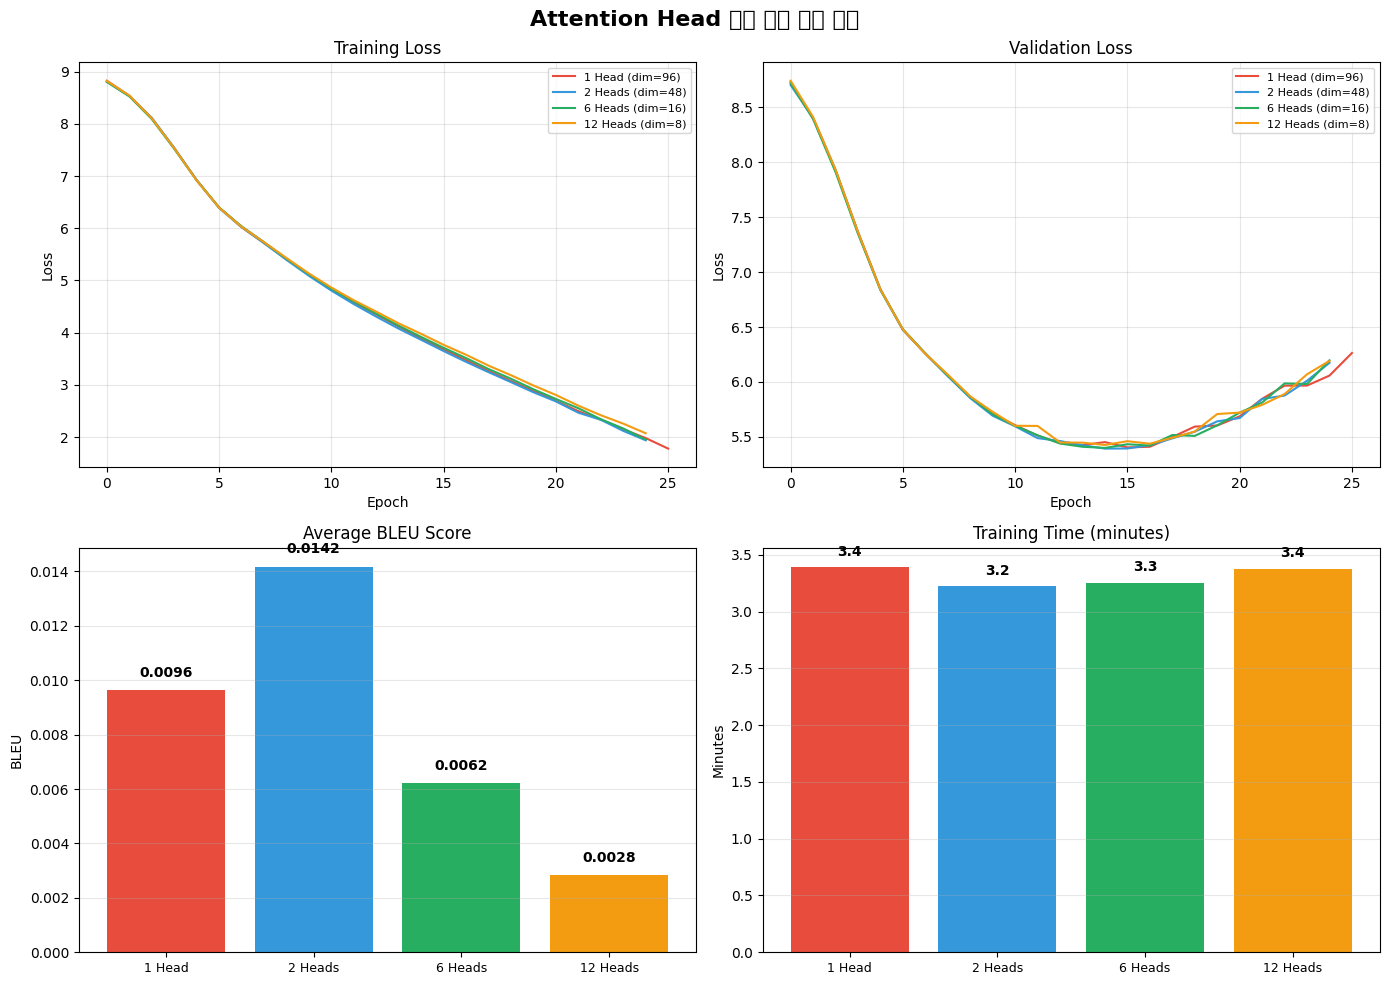


설정                     |   val_loss |    val_acc |     BLEU |    시간(분)
----------------------------------------------------------------------
1 Head (dim=96)        |     5.4052 |     0.2114 |   0.0096 |      3.4
2 Heads (dim=48)       |     5.3942 |     0.2150 |   0.0142 |      3.2
6 Heads (dim=16)       |     5.4005 |     0.2092 |   0.0062 |      3.3
12 Heads (dim=8)       |     5.4274 |     0.2090 |   0.0028 |      3.4


In [16]:
# Cell 16: 실험 B 결과 시각화
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Attention Head 수에 따른 성능 비교', fontsize=16, fontweight='bold')
colors = ['#e74c3c', '#3498db', '#27ae60', '#f39c12']

ax = axes[0, 0]
for i, (name, r) in enumerate(results.items()):
    ax.plot(r['history']['loss'], color=colors[i], label=name, linewidth=1.5)
ax.set_title('Training Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
for i, (name, r) in enumerate(results.items()):
    ax.plot(r['history']['val_loss'], color=colors[i], label=name, linewidth=1.5)
ax.set_title('Validation Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
names = list(results.keys())
bleus = [results[n]['avg_bleu'] for n in names]
bars  = ax.bar(range(len(names)), bleus, color=colors)
ax.set_title('Average BLEU Score')
ax.set_xticks(range(len(names)))
ax.set_xticklabels([n.split('(')[0].strip() for n in names], fontsize=9)
ax.set_ylabel('BLEU')
for bar, val in zip(bars, bleus):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
            f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1, 1]
times = [results[n]['train_time'] / 60 for n in names]
bars  = ax.bar(range(len(names)), times, color=colors)
ax.set_title('Training Time (minutes)')
ax.set_xticks(range(len(names)))
ax.set_xticklabels([n.split('(')[0].strip() for n in names], fontsize=9)
ax.set_ylabel('Minutes')
for bar, val in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1f}', ha='center', fontsize=10, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('exp_b_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'설정':<22} | {'val_loss':>10} | {'val_acc':>10} | {'BLEU':>8} | {'시간(분)':>8}")
print('-' * 70)
for name, r in results.items():
    print(f"{name:<22} | {r['best_val_loss']:>10.4f} | "
          f"{r['best_val_acc']:>10.4f} | {r['avg_bleu']:>8.4f} | "
          f"{r['train_time']/60:>8.1f}")

---
# 실험 A: Attention Head 패턴 시각화

6-Head 모델을 가져와서 각 Head가 실제로 다른 패턴을 포착하는지 heatmap으로 확인한다.

Head마다 어떤 토큰에 얼마나 집중하는지가 다르게 나온다면 역할 분화가 있다고 볼 수 있다.

분석 문장: "este e um problema que temos que resolver."

--- Encoder Layer 0 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:1035: UserWarning: Layer 'global_self_attention_6' (of type GlobalSelfAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:1035: UserWarning: Layer 'encoder_layer_6' (of type EncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


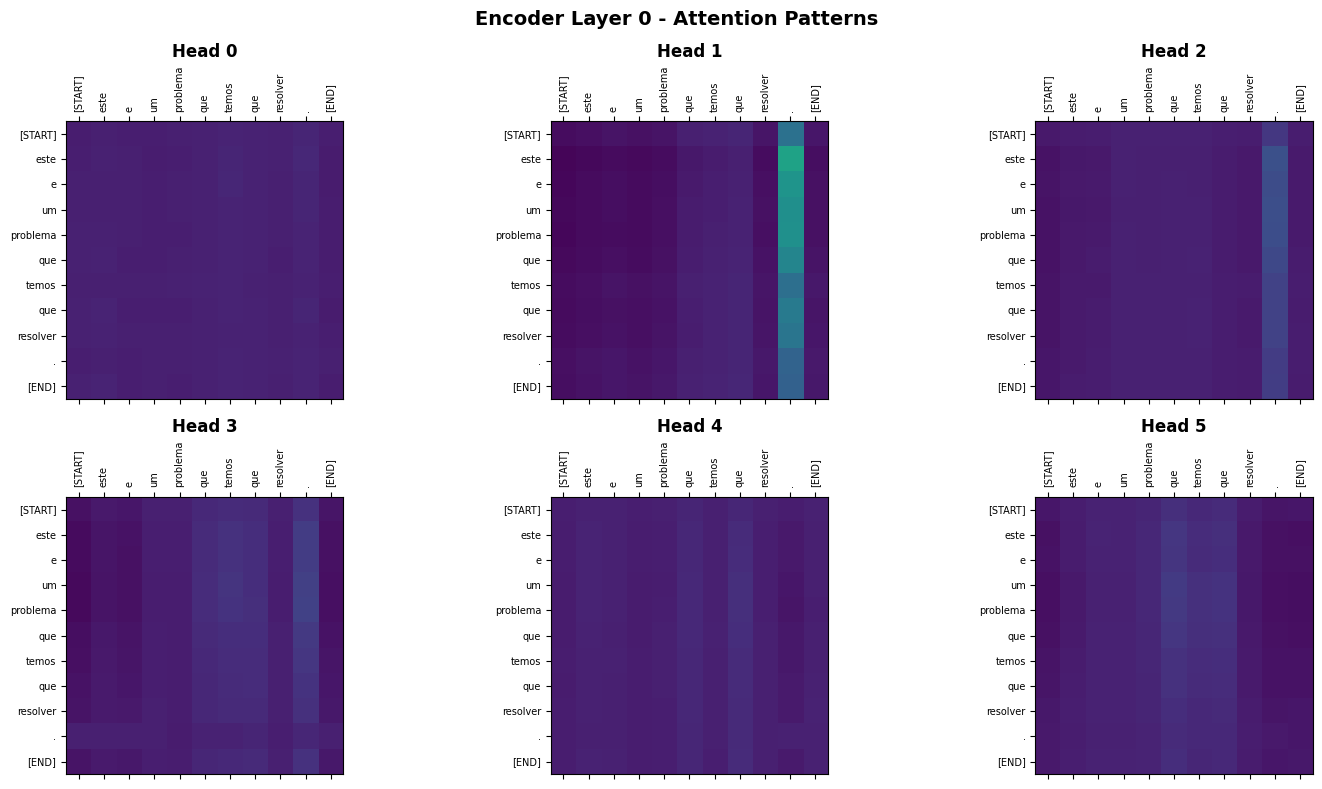

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:1035: UserWarning: Layer 'global_self_attention_6' (of type GlobalSelfAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:1035: UserWarning: Layer 'encoder_layer_6' (of type EncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


--- Encoder Layer 1 ---


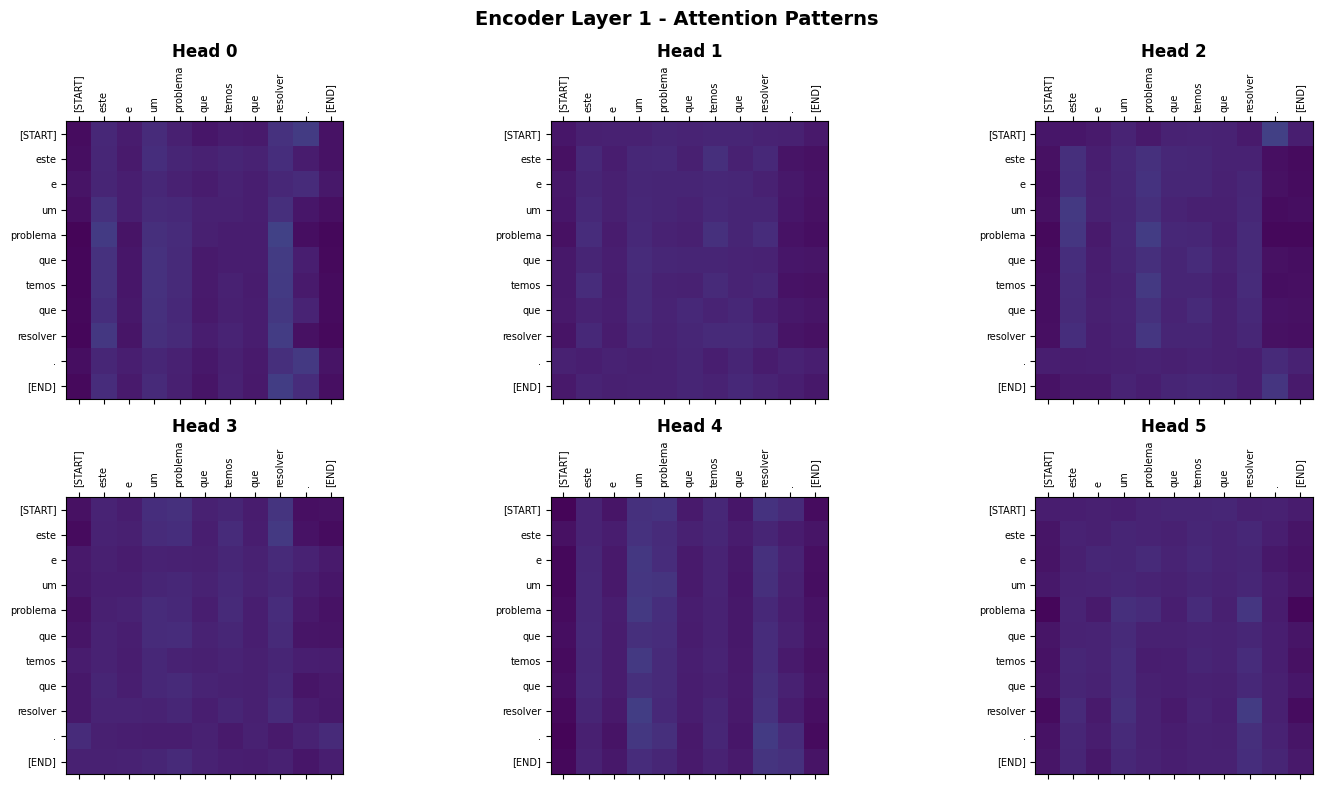

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:1035: UserWarning: Layer 'global_self_attention_6' (of type GlobalSelfAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:1035: UserWarning: Layer 'encoder_layer_6' (of type EncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


--- Encoder Layer 2 ---


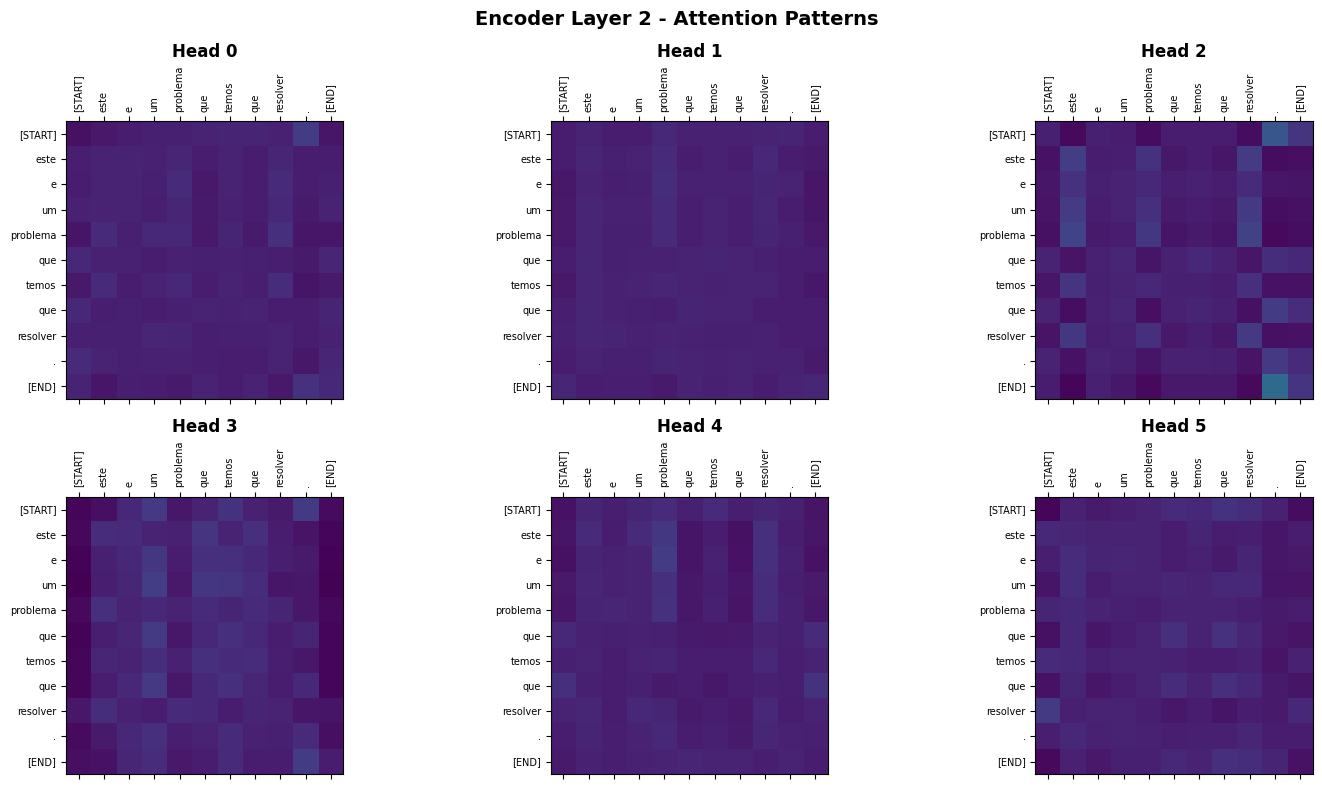

In [17]:
# Cell 17: Attention Head 패턴 시각화
base_model = results['6 Heads (dim=16)']['model']

def visualize_encoder_heads(model, sentence, tokenizers, layer_idx=0):
    in_tokens = tokenizers.pt.tokenize(tf.constant([sentence])).to_tensor()
    _ = model.encoder(in_tokens, training=False)

    attn = model.encoder.enc_layers[layer_idx].self_attention.last_attn_scores
    attn = tf.squeeze(attn, 0).numpy()

    token_labels = tokenizers.pt.lookup(in_tokens)[0].numpy()
    token_labels = [t.decode('utf-8') for t in token_labels]

    n_heads = attn.shape[0]
    cols    = min(n_heads, 3)
    rows    = (n_heads + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
    if n_heads == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for h in range(n_heads):
        ax = axes[h]
        ax.matshow(attn[h], cmap='viridis', vmin=0, vmax=1)
        ax.set_title(f'Head {h}', fontsize=12, fontweight='bold')
        ax.set_xticks(range(len(token_labels)))
        ax.set_xticklabels(token_labels, rotation=90, fontsize=7)
        ax.set_yticks(range(len(token_labels)))
        ax.set_yticklabels(token_labels, fontsize=7)

    for h in range(n_heads, len(axes)):
        axes[h].set_visible(False)

    fig.suptitle(f'Encoder Layer {layer_idx} - Attention Patterns', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'attention_layer{layer_idx}.png', dpi=150, bbox_inches='tight')
    plt.show()
    return attn


test_sent = 'este e um problema que temos que resolver.'
print(f'분석 문장: "{test_sent}"\n')

all_attn = {}
for layer_idx in range(3):
    print(f'--- Encoder Layer {layer_idx} ---')
    all_attn[layer_idx] = visualize_encoder_heads(base_model, test_sent, tokenizers, layer_idx)

=== Attention Entropy 분석 ===
(높을수록 분산 패턴, 낮을수록 집중 패턴)

Encoder Layer 0:
  Head 0: entropy = 2.3952 (분산 패턴)
  Head 1: entropy = 1.9366 (집중 패턴)
  Head 2: entropy = 2.3235 (집중 패턴)
  Head 3: entropy = 2.3153 (집중 패턴)
  Head 4: entropy = 2.3845 (분산 패턴)
  Head 5: entropy = 2.3306 (분산 패턴)

Encoder Layer 1:
  Head 0: entropy = 2.2889 (집중 패턴)
  Head 1: entropy = 2.3634 (분산 패턴)
  Head 2: entropy = 2.3175 (집중 패턴)
  Head 3: entropy = 2.3617 (분산 패턴)
  Head 4: entropy = 2.2997 (집중 패턴)
  Head 5: entropy = 2.3566 (분산 패턴)

Encoder Layer 2:
  Head 0: entropy = 2.3773 (분산 패턴)
  Head 1: entropy = 2.3873 (분산 패턴)
  Head 2: entropy = 2.2679 (집중 패턴)
  Head 3: entropy = 2.2695 (집중 패턴)
  Head 4: entropy = 2.3645 (분산 패턴)
  Head 5: entropy = 2.3585 (집중 패턴)


=== Head 간 코사인 유사도 (Layer 0) ===


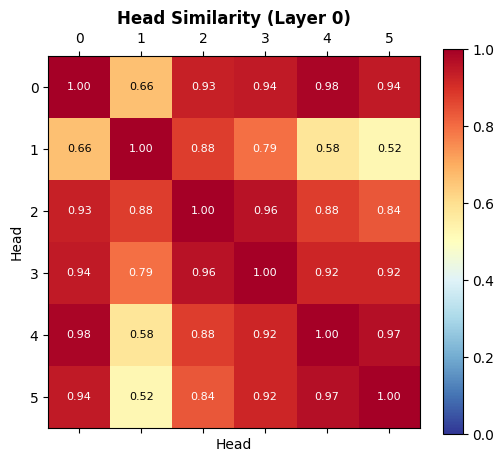


유사도가 높은 Head 쌍 (>0.8):
  Head 0 - Head 2: 0.931
  Head 0 - Head 3: 0.945
  Head 0 - Head 4: 0.984
  Head 0 - Head 5: 0.943
  Head 1 - Head 2: 0.876
  Head 2 - Head 3: 0.959
  Head 2 - Head 4: 0.879
  Head 2 - Head 5: 0.835
  Head 3 - Head 4: 0.920
  Head 3 - Head 5: 0.919
  Head 4 - Head 5: 0.965


In [18]:
# Cell 18: Entropy 및 Head 유사도 분석
def attention_entropy(attn_weights):
    eps     = 1e-10
    entropy = -np.sum(attn_weights * np.log(attn_weights + eps), axis=-1)
    return entropy.mean(axis=-1)

def head_similarity(attn_weights):
    n_heads   = attn_weights.shape[0]
    flat      = attn_weights.reshape(n_heads, -1)
    norms     = np.linalg.norm(flat, axis=1, keepdims=True) + 1e-10
    flat_norm = flat / norms
    return flat_norm @ flat_norm.T

print('=== Attention Entropy 분석 ===')
print('(높을수록 분산 패턴, 낮을수록 집중 패턴)\n')

for layer_idx in range(3):
    entropy = attention_entropy(all_attn[layer_idx])
    print(f'Encoder Layer {layer_idx}:')
    for h, e in enumerate(entropy):
        pattern = '분산' if e > np.median(entropy) else '집중'
        print(f'  Head {h}: entropy = {e:.4f} ({pattern} 패턴)')
    print()

print('\n=== Head 간 코사인 유사도 (Layer 0) ===')
sim = head_similarity(all_attn[0])

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.matshow(sim, cmap='RdYlBu_r', vmin=0, vmax=1)
ax.set_title('Head Similarity (Layer 0)', fontweight='bold')
ax.set_xlabel('Head')
ax.set_ylabel('Head')
plt.colorbar(im)
for i in range(sim.shape[0]):
    for j in range(sim.shape[1]):
        ax.text(j, i, f'{sim[i,j]:.2f}', ha='center', va='center',
                fontsize=8, color='black' if sim[i,j] < 0.7 else 'white')
plt.savefig('head_similarity.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n유사도가 높은 Head 쌍 (>0.8):')
for i in range(sim.shape[0]):
    for j in range(i+1, sim.shape[1]):
        if sim[i, j] > 0.8:
            print(f'  Head {i} - Head {j}: {sim[i,j]:.3f}')

---
# 실험 C: Head Pruning

6-Head 모델(3 layers x 6 heads = 18개)에서 Head를 하나씩 0으로 마스킹한 뒤 val_loss 변화를 측정

재학습 없이 각 Head의 기여도를 빠르게 측정하는 방식,

변화가 거의 없다면 그 Head는 제거해도 무방하다고 볼 수 있음

In [19]:
# Cell 19: Head Pruning 중요도 측정
def evaluate_model(model, val_batches):
    res = model.evaluate(val_batches, verbose=0)
    return {'val_loss': res[0], 'val_acc': res[1]}

def mask_head(model, layer_idx, head_idx, num_heads, d_model):
    enc_layer = model.encoder.enc_layers[layer_idx]
    dense     = enc_layer.self_attention.mha._output_dense
    weights   = dense.get_weights()
    head_dim  = d_model // num_heads
    start     = head_idx * head_dim
    end       = start + head_dim
    weights[0][start:end, :] = 0
    dense.set_weights(weights)

model      = results['6 Heads (dim=16)']['model']
NUM_HEADS  = 6
D_MODEL    = 96
NUM_LAYERS = 3

baseline = evaluate_model(model, val_batches)
print(f"Baseline - val_loss: {baseline['val_loss']:.4f}, val_acc: {baseline['val_acc']:.4f}")

print('\n=== Head별 중요도 측정 (마스킹 후 val_loss 변화) ===')
importance = {}

for layer_idx in range(NUM_LAYERS):
    print(f'\n--- Encoder Layer {layer_idx} ---')
    for head_idx in range(NUM_HEADS):
        enc_layer  = model.encoder.enc_layers[layer_idx]
        dense      = enc_layer.self_attention.mha._output_dense
        original_w = [w.copy() for w in dense.get_weights()]

        mask_head(model, layer_idx, head_idx, NUM_HEADS, D_MODEL)
        masked_result = evaluate_model(model, val_batches)
        loss_increase = masked_result['val_loss'] - baseline['val_loss']
        importance[(layer_idx, head_idx)] = loss_increase
        print(f'  Head {head_idx}: val_loss 변화 = +{loss_increase:.4f}')

        dense.set_weights(original_w)

Baseline - val_loss: 5.3945, val_acc: 0.1982

=== Head별 중요도 측정 (마스킹 후 val_loss 변화) ===

--- Encoder Layer 0 ---
  Head 0: val_loss 변화 = +0.0724
  Head 1: val_loss 변화 = +0.0024
  Head 2: val_loss 변화 = +0.0064
  Head 3: val_loss 변화 = +0.0080
  Head 4: val_loss 변화 = +0.0059
  Head 5: val_loss 변화 = +0.0049

--- Encoder Layer 1 ---
  Head 0: val_loss 변화 = +0.0098
  Head 1: val_loss 변화 = +0.0060
  Head 2: val_loss 변화 = +-0.0018
  Head 3: val_loss 변화 = +0.0073
  Head 4: val_loss 변화 = +0.0058
  Head 5: val_loss 변화 = +0.0080

--- Encoder Layer 2 ---
  Head 0: val_loss 변화 = +0.0236
  Head 1: val_loss 변화 = +0.0054
  Head 2: val_loss 변화 = +0.0047
  Head 3: val_loss 변화 = +0.0014
  Head 4: val_loss 변화 = +0.0067
  Head 5: val_loss 변화 = +0.0010


Head 중요도 순위 (낮은순 = 제거 우선):
  1. Layer 1 Head 2: +-0.0018
  2. Layer 2 Head 5: +0.0010
  3. Layer 2 Head 3: +0.0014
  4. Layer 0 Head 1: +0.0024
  5. Layer 2 Head 2: +0.0047
  6. Layer 0 Head 5: +0.0049
  7. Layer 2 Head 1: +0.0054
  8. Layer 1 Head 4: +0.0058
  9. Layer 0 Head 4: +0.0059
  10. Layer 1 Head 1: +0.0060
  11. Layer 0 Head 2: +0.0064
  12. Layer 2 Head 4: +0.0067
  13. Layer 1 Head 3: +0.0073
  14. Layer 0 Head 3: +0.0080
  15. Layer 1 Head 5: +0.0080
  16. Layer 1 Head 0: +0.0098
  17. Layer 2 Head 0: +0.0236
  18. Layer 0 Head 0: +0.0724
Pruned 1/18 heads: val_loss=5.3910, val_acc=0.1987
Pruned 2/18 heads: val_loss=5.4050, val_acc=0.1973
Pruned 3/18 heads: val_loss=5.4000, val_acc=0.1976
Pruned 4/18 heads: val_loss=5.4023, val_acc=0.1969
Pruned 5/18 heads: val_loss=5.3837, val_acc=0.1988
Pruned 6/18 heads: val_loss=5.3979, val_acc=0.1980
Pruned 7/18 heads: val_loss=5.4015, val_acc=0.1974
Pruned 8/18 heads: val_loss=5.3999, val_acc=0.1976
Pruned 9/18 heads: val_loss=5.392

Pruned 18/18 heads: val_loss=5.4634, val_acc=0.1947


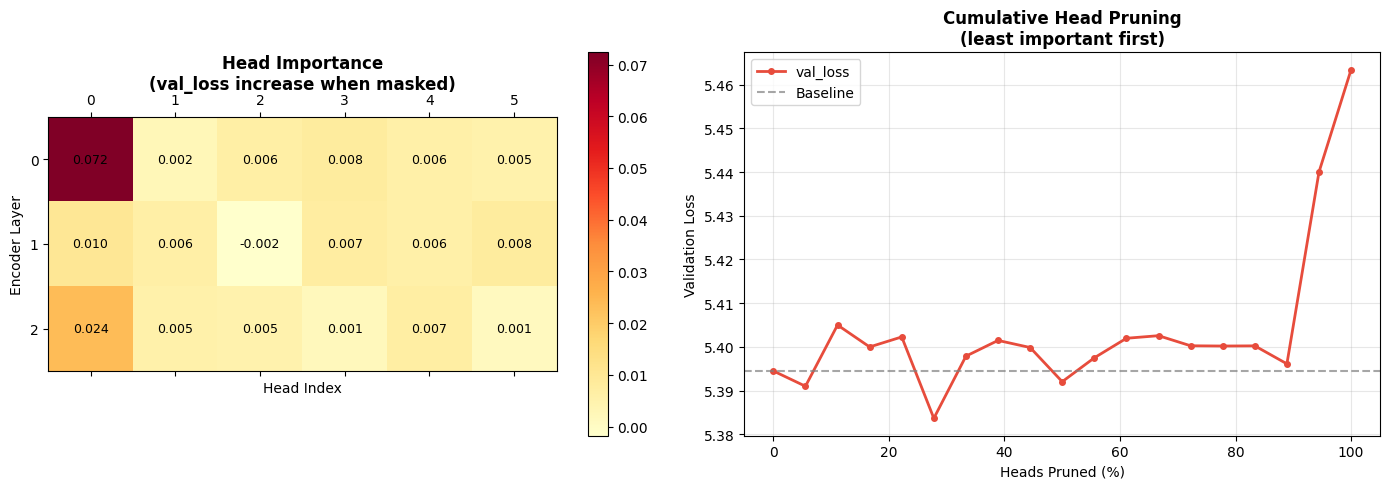

In [20]:
# Cell 20: Pruning 결과 시각화
imp_matrix = np.zeros((NUM_LAYERS, NUM_HEADS))
for (l, h), val in importance.items():
    imp_matrix[l, h] = val

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
im = ax.matshow(imp_matrix, cmap='YlOrRd')
ax.set_title('Head Importance\n(val_loss increase when masked)', fontweight='bold', pad=20)
ax.set_xlabel('Head Index')
ax.set_ylabel('Encoder Layer')
ax.set_xticks(range(NUM_HEADS))
ax.set_yticks(range(NUM_LAYERS))
plt.colorbar(im, ax=ax)
for i in range(NUM_LAYERS):
    for j in range(NUM_HEADS):
        ax.text(j, i, f'{imp_matrix[i,j]:.3f}', ha='center', va='center', fontsize=9)

sorted_heads = sorted(importance.items(), key=lambda x: x[1])
print('Head 중요도 순위 (낮은순 = 제거 우선):')
for rank, ((l, h), imp) in enumerate(sorted_heads):
    print(f'  {rank+1}. Layer {l} Head {h}: +{imp:.4f}')

all_original_weights = {}
for layer_idx in range(NUM_LAYERS):
    for head_idx in range(NUM_HEADS):
        enc_layer = model.encoder.enc_layers[layer_idx]
        dense     = enc_layer.self_attention.mha._output_dense
        all_original_weights[(layer_idx, head_idx)] = [w.copy() for w in dense.get_weights()]

for (l, h), w in all_original_weights.items():
    enc_layer = model.encoder.enc_layers[l]
    dense     = enc_layer.self_attention.mha._output_dense
    dense.set_weights(w)

cumulative_losses = [baseline['val_loss']]
cumulative_accs   = [baseline['val_acc']]
pruned_count      = [0]

for i, ((l, h), _) in enumerate(sorted_heads):
    mask_head(model, l, h, NUM_HEADS, D_MODEL)
    result = evaluate_model(model, val_batches)
    cumulative_losses.append(result['val_loss'])
    cumulative_accs.append(result['val_acc'])
    pruned_count.append(i + 1)
    print(f"Pruned {i+1}/{NUM_HEADS*NUM_LAYERS} heads: val_loss={result['val_loss']:.4f}, val_acc={result['val_acc']:.4f}")

for (l, h), w in all_original_weights.items():
    enc_layer = model.encoder.enc_layers[l]
    dense     = enc_layer.self_attention.mha._output_dense
    dense.set_weights(w)

ax = axes[1]
total_heads = NUM_HEADS * NUM_LAYERS
x_pct = [n / total_heads * 100 for n in pruned_count]
ax.plot(x_pct, cumulative_losses, 'o-', color='#e74c3c', linewidth=2, markersize=4, label='val_loss')
ax.axhline(y=baseline['val_loss'], color='gray', linestyle='--', alpha=0.7, label='Baseline')
ax.set_title('Cumulative Head Pruning\n(least important first)', fontweight='bold')
ax.set_xlabel('Heads Pruned (%)')
ax.set_ylabel('Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('head_pruning_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# Cell 21: 결과 저장
summary = {}
for name, r in results.items():
    summary[name] = {
        'num_heads':      r['num_heads'],
        'head_dim':       r['head_dim'],
        'best_val_loss':  float(r['best_val_loss']),
        'best_val_acc':   float(r['best_val_acc']),
        'avg_bleu':       float(r['avg_bleu']),
        'train_time_sec': float(r['train_time']),
    }

with open('experiment_results.json', 'w') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print('결과 저장 완료: experiment_results.json')
print('\n생성된 파일:')
print('  attention_layer0~2.png / head_similarity.png (실험 A)')
print('  exp_b_results.png (실험 B)')
print('  head_pruning_results.png (실험 C)')
print('  experiment_results.json')

결과 저장 완료: experiment_results.json

생성된 파일:
  attention_layer0~2.png / head_similarity.png (실험 A)
  exp_b_results.png (실험 B)
  head_pruning_results.png (실험 C)
  experiment_results.json
